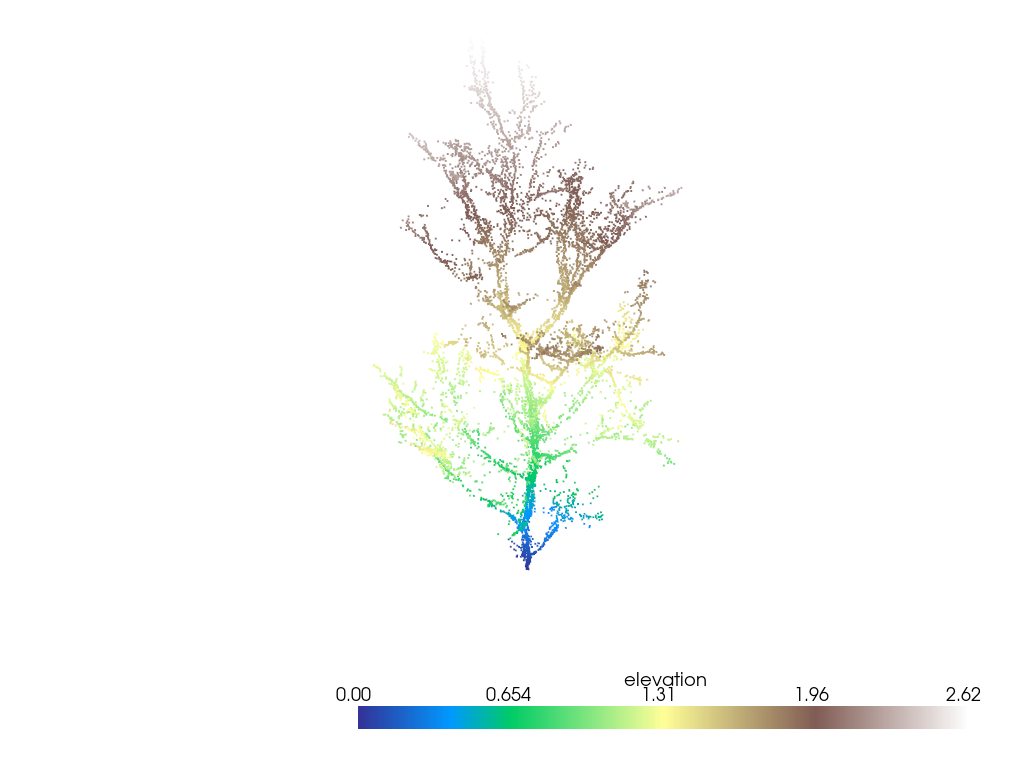

In [73]:
import laspy
import pyvista as pv
import numpy as np

las = laspy.read('data/train_data/17366.laz')
points = np.vstack((las.x, las.y, las.z)).transpose()
centered_points = points - np.min(points, axis=0)

cloud = pv.PolyData(centered_points)
cloud["elevation"] = points[:,2]

# --- LE FIX POUR VS CODE ---
pv.set_jupyter_backend('static') 
# ---------------------------

plotter = pv.Plotter()
plotter.add_mesh(cloud, scalars="elevation", cmap="terrain", point_size=2)
plotter.show()

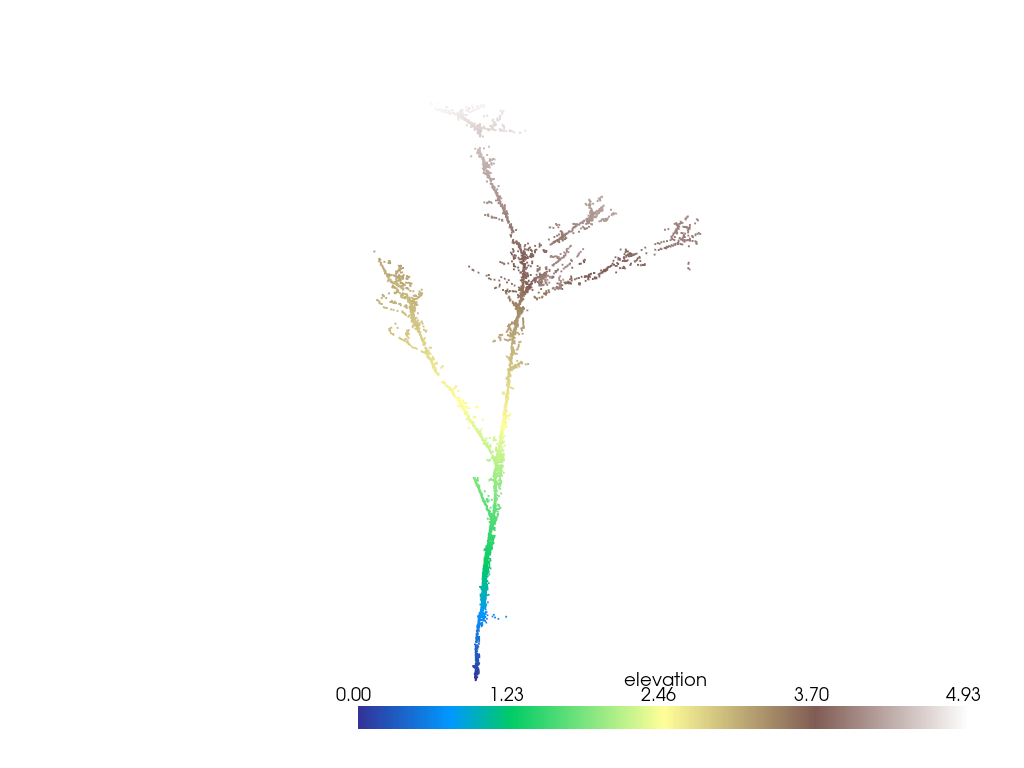

In [16]:
import laspy
import pyvista as pv
import numpy as np

las = laspy.read('data/train_data/18012.laz')
points = np.vstack((las.x, las.y, las.z)).transpose()
centered_points = points - np.min(points, axis=0)

cloud = pv.PolyData(centered_points)
cloud["elevation"] = points[:,2]

# --- LE FIX POUR VS CODE ---
pv.set_jupyter_backend('static') 
# ---------------------------

plotter = pv.Plotter()
plotter.add_mesh(cloud, scalars="elevation", cmap="terrain", point_size=2)
plotter.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html lang=&quot;en-US&quot; dir=&quot;ltr&quot;>\n  …

In [ ]:
from utils.feature_extraction import get_robust_dbh, get_trunk_height
import os

def test_visualize(laz_file_path):
    las = laspy.read(laz_file_path)
    points = np.vstack((las.x, las.y, las.z)).transpose()
    points = points - np.min(points, axis = 0)
    z_max = np.max(points[:, 2])
    z_min = np.min(points[:, 2])

    tree_height = z_max - z_min

    stem_diameter, stem_quality = get_robust_dbh(points, z_min, z_max)

    trunk_height = get_trunk_height(stem_diameter, points, z_max, z_min)

    target_z_start = z_min + 1.3 if tree_height > 2.0 else z_min + (0.2 * tree_height)
    target_z_end = target_z_start + 0.2
    dbh_mask = (points[:, 2] >= target_z_start) & (points[:, 2] <= target_z_end)
    
    # Identify the Crown
    crown_mask = points[:, 2] > (z_min + trunk_height)

    # 4. Assign Colors (RGB normalized 0-1)
    # Default: Brown for Trunk
    colors = np.full((points.shape[0], 3), [0.45, 0.24, 0.14]) 
    
    # Green for Crown
    colors[crown_mask] = [0.13, 0.55, 0.13] 
    
    # Red for DBH Slice
    colors[dbh_mask] = [1.0, 0.0, 0.0]

    # 5. Create PyVista Object
    cloud = pv.PolyData(points)
    cloud["colors"] = colors

    print(f"--- DEBUG {os.path.basename(laz_file_path)} ---")
    print(f"Diamètre tronc trouvé: {stem_diameter*2:.3f}m")
    print(f"Qualité RANSAC: {stem_quality:.2%}")
    print(f"Hauteur tronc calculée: {trunk_height:.2f}m")

    # 6. Plotting
    plotter = pv.Plotter(title=f"Tree: {laz_file_path}")
    plotter.set_background("#1a1a1a")
    plotter.add_points(cloud, scalars="colors", rgb=True, point_size=2.0, render_points_as_spheres=True)
    
    # Add a text label for metadata validation
    label = (f"Stem Diameter: {stem_diameter*2:.2f}m\n"
             f"Trunk Height: {trunk_height:.2f}m\n"
             f"Quality: {stem_quality:.2%}")
    plotter.add_text(label, position='upper_left', font_size=10, color='white')
    
    # Add a horizontal plane to clearly show the Trunk/Crown split
    plane_z = z_min + trunk_height
    center_xy = np.mean(points[:, :2], axis=0)
    grid = pv.Plane(center=(center_xy[0], center_xy[1], plane_z), i_size=2, j_size=2)
    plotter.add_mesh(grid, color="white", opacity=0.3, label="Crown Base")

    plotter.show(jupyter_backend = "static")


4399
--- DEBUG 00073.laz ---
Diamètre tronc trouvé: 0.258m
Qualité RANSAC: 96.95%
Hauteur tronc calculée: 5.60m


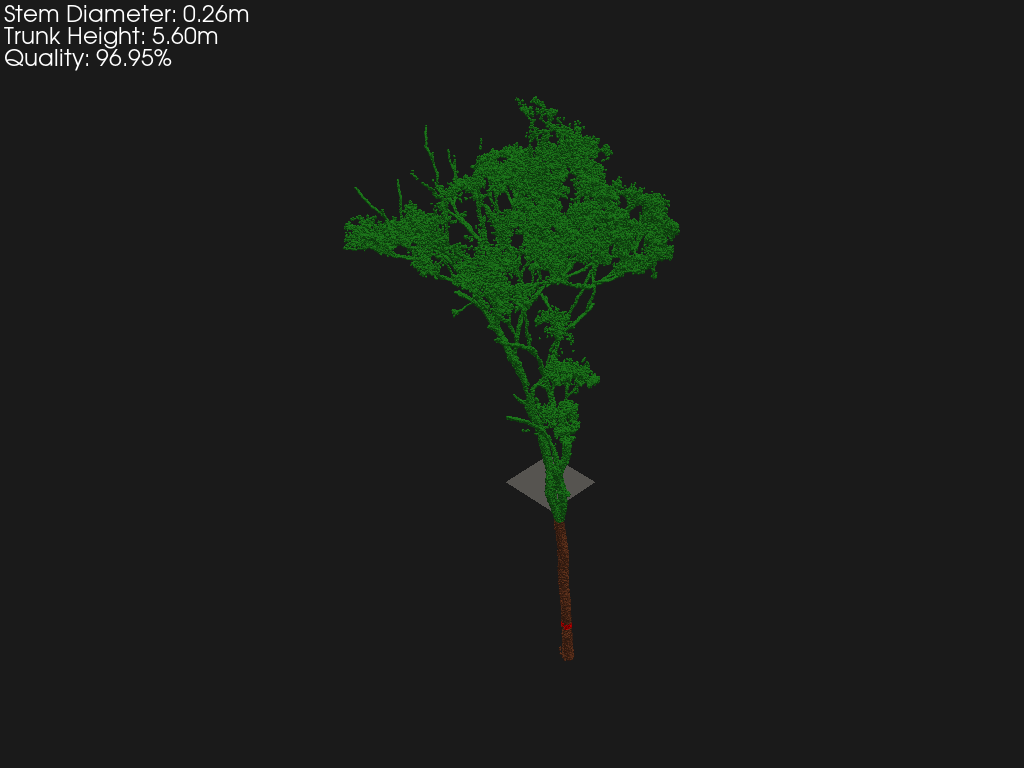

In [15]:
test_visualize("data/train_data/00073.laz")

In [3]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv("data/pcf_dataset.csv")

# parse the array string from the single pcf column
def parse_array(s):
    return [float(v) for v in re.sub(r'[\[\]\n]', ' ', str(s)).split()]

parsed = df["pcf_t_0.0500"].apply(parse_array)
n = len(parsed.iloc[0])
t_values = np.linspace(1/n, 1, n)
pcf_cols = [f"pcf_t_{t:.4f}" for t in t_values]

meta = [c for c in df.columns if not c.startswith("pcf_t_")]
df = pd.concat([df[meta], pd.DataFrame(parsed.tolist(), columns=pcf_cols)], axis=1)
df.to_csv("data/pcf_dataset.csv", index=False)
df.head()

,treeID,species,genus,dataset,data_type,tree_H,r_max,pcf_t_0.0500,pcf_t_0.1000,pcf_t_0.1500,...,pcf_t_0.5500,pcf_t_0.6000,pcf_t_0.6500,pcf_t_0.7000,pcf_t_0.7500,pcf_t_0.8000,pcf_t_0.8500,pcf_t_0.9000,pcf_t_0.9500,pcf_t_1.0000
0,80,Eucalyptus_miniata,Eucalyptus,Luck,TLS,7.107000,3.5535,0.364601,0.224767,0.139602,...,0.016885,0.011287,0.005942,0.003425,0.002512,0.002061,0.001916,0.001832,0.001727,0.001711
1,81,Eucalyptus_miniata,Eucalyptus,Luck,TLS,6.031000,3.0155,2.143381,0.475849,0.229767,...,0.018577,0.017270,0.012543,0.010196,0.009809,0.006551,0.009027,0.005989,0.007567,0.005071
2,82,Eucalyptus_miniata,Eucalyptus,Luck,TLS,16.708001,5.0000,0.027243,0.010726,0.006755,...,0.002486,0.002217,0.002023,0.001873,0.001762,0.001617,0.001450,0.001378,0.001261,0.001180
3,83,Eucalyptus_miniata,Eucalyptus,Luck,TLS,18.992999,5.0000,0.012260,0.004835,0.002968,...,0.001409,0.001406,0.001397,0.001294,0.001211,0.001144,0.001080,0.001023,0.000933,0.000879
4,98,Eucalyptus_miniata,Eucalyptus,Luck,TLS,21.402000,5.0000,0.052747,0.014383,0.007845,...,0.001780,0.001579,0.001466,0.001430,0.001303,0.001199,0.001095,0.000996,0.000927,0.000824
